Semi-discrete transport: the c-transform
========================================

**When to use:** one side is a density you can sample densely (a grid, or any large set of points) and the other a
set of sites, as in quantization, power (Laguerre) diagrams or semi-dual training objectives.

**What you will see:** a million grid points and 10,000 sites; the c-transform and its argmin, which split the
square into cells; L-BFGS on the semi-dual, which reduces the errors of the cell masses; and how far it gets.

Source: [plot_semi_dual.py](plot_semi_dual.py) · [Gallery](../README.md)

Reference figures and quoted results come from previous script runs. They are reading aids, not outputs from an execution of this notebook.

Install `pip install --upgrade 'flash-sinkhorn[notebooks]'`, clone this repository for the example files, and start `jupyter lab` from the checkout. Select its Python environment, then run the cells in order on an NVIDIA CUDA GPU. The setup cell finds the checkout from the repository root or this notebook's folder. The solver comes from the installed package. Running all cells prints fresh results and displays new figures; it also replaces the source's saved images. The scale examples retain the script's full problem sizes.

In [ ]:
# Find this checkout when Jupyter starts at its root or in a notebook folder.
import os
import sys
from pathlib import Path

for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'examples/advanced/plot_semi_dual.py').is_file() and (_candidate / "torch-ext/flash_sinkhorn").is_dir():
        _notebook_root = _candidate
        break
else:
    raise RuntimeError("Start Jupyter inside the flash-sinkhorn repository checkout.")

os.chdir(_notebook_root)
# Locate shared example helpers; import the solver from the installed package.
for _path in reversed([_notebook_root / "examples", _notebook_root]):
    if str(_path) in sys.path:
        sys.path.remove(str(_path))
    sys.path.insert(0, str(_path))
__file__ = str(_notebook_root / 'examples/advanced/plot_semi_dual.py')

# Display the saved PNG/GIF files explicitly, including figures closed by the source.
import matplotlib
matplotlib.use("Agg")

Setup
-----

In [ ]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from flash_sinkhorn import c_transform_cost, c_transform_fwd

sys.path.append(str(Path(__file__).resolve().parents[1]))  # the gallery's shared helpers
from _plotting import dense_size, images_dir, require_cuda, save, table, timed, to_numpy  # noqa: E402

device = require_cuda()
torch.manual_seed(0)
side = 1000
u = (torch.arange(side, device=device) + 0.5) / side
x = torch.stack(torch.meshgrid(u, u, indexing="ij"), dim=-1).reshape(-1, 2)  # 10^6 grid points
m = 10_000
y = torch.rand(m, 2, device=device)  # sites
a = torch.full((len(x),), 1.0 / len(x), device=device)
b = torch.full((m,), 1.0 / m, device=device)
print(dense_size(len(x), m))

The c-transform
---------------
``c_transform_fwd`` returns, for each grid point, min_j (cost_scale |x - y_j|^2 - psi_j) and the index j that
attains it, streaming over the sites. With psi = 0 the cells are the Voronoi cells of the sites, and their masses
differ widely. Both calls here run in FP32 (``allow_tf32=False``). TF32, the default, first rounds the coordinates
to TF32, and with sites this close together that moves some grid points to another cell; the last line below
counts them.

In [ ]:
def cells(psi, allow_tf32=False):
    return c_transform_fwd(x, y, psi, cost_scale=0.5, allow_tf32=allow_tf32, autotune=False)[1]


def mass_errors(psi):
    """L1 error of the cell masses, and the worst relative error of one cell."""
    mass = torch.bincount(cells(psi), minlength=m).float() / len(x)
    return (mass - b).abs().sum().item(), ((mass - b).abs() / b).max().item()


voronoi = timed("c-transform of 10^6 points against 10^4 sites", lambda: cells(torch.zeros(m, device=device)))
moved = (cells(torch.zeros(m, device=device), allow_tf32=True) != voronoi).float().mean().item()
print(f"grid points in another cell with TF32: {moved:.1%}")

Fitting the masses: the semi-dual
---------------------------------
The semi-dual L(psi) = sum_i a_i c^psi(x_i) + sum_j b_j psi_j is concave in psi, and its gradient b_j - mass_j
vanishes when every cell holds mass b_j. ``c_transform_cost`` returns L, and autograd gives its gradient (Danskin's
theorem), so a standard optimizer can maximize it; here L-BFGS. Each cell should hold 100 grid points; the table
shows how close L-BFGS gets.

In [ ]:
psi = torch.zeros(m, device=device, requires_grad=True)
optimizer = torch.optim.LBFGS([psi], lr=1.0, max_iter=20, history_size=20, line_search_fn="strong_wolfe")


def closure():
    optimizer.zero_grad()
    loss = -c_transform_cost(x, y, psi, cost_scale=0.5, allow_tf32=False, autotune=False, a=a, b=b)
    loss.backward()
    return loss


rows = [["0", "0.0 s", *[f"{e:.3f}" for e in mass_errors(psi.detach())]]]
torch.cuda.synchronize()
start = time.perf_counter()
for rounds in range(1, 11):
    optimizer.step(closure)
    if rounds in (1, 2, 5, 10):
        torch.cuda.synchronize()
        elapsed = time.perf_counter() - start
        iterations = optimizer.state[psi]["n_iter"]  # L-BFGS may stop a round early
        rows.append([str(iterations), f"{elapsed:.1f} s", *[f"{e:.3f}" for e in mass_errors(psi.detach())]])
        print(f"{iterations} L-BFGS iterations, {elapsed:.1f} s: L1 mass error {rows[-1][2]}, worst cell {rows[-1][3]}")
print(f"peak memory {torch.cuda.max_memory_allocated() / 2**30:.2f} GiB on {torch.cuda.get_device_name()}")

Figure
------
The lower-left corner of the square, before (Voronoi) and after fitting (Laguerre): each cell coloured by its mass
relative to b_j (white is exact), with the cell boundaries in grey; and the errors.

In [ ]:
corner = side // 4


def cell_image(labels):
    ratio = (torch.bincount(labels, minlength=m).float() / len(x) / b)[labels].reshape(side, side)[:corner, :corner]
    grid = labels.reshape(side, side)[:corner, :corner]
    boundary = torch.zeros_like(grid, dtype=torch.bool)
    boundary[1:, :] |= grid[1:, :] != grid[:-1, :]
    boundary[:, 1:] |= grid[:, 1:] != grid[:, :-1]
    return to_numpy(ratio.masked_fill(boundary, float("nan")).T)  # rows of the image are the second coordinate


colours = plt.get_cmap("coolwarm").copy()
colours.set_bad("0.3")
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.8), gridspec_kw=dict(width_ratios=[1, 1, 1.1]))
for ax, labels, title in ((axes[0], voronoi, "psi = 0: Voronoi cells"),
                          (axes[1], cells(psi.detach()), "after L-BFGS: Laguerre cells")):
    image = ax.imshow(cell_image(labels), origin="lower", interpolation="nearest", cmap=colours, vmin=0, vmax=2)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(image, ax=axes[:2].tolist(), orientation="horizontal", fraction=0.05, pad=0.04, label="cell mass / b_j")
table(axes[2], ["L-BFGS iterations", "time", "L1 mass error", "worst cell"], rows, fontsize=9)
save(fig, images_dir(__file__), "semi_dual")
plt.show()

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/advanced/images/semi_dual.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

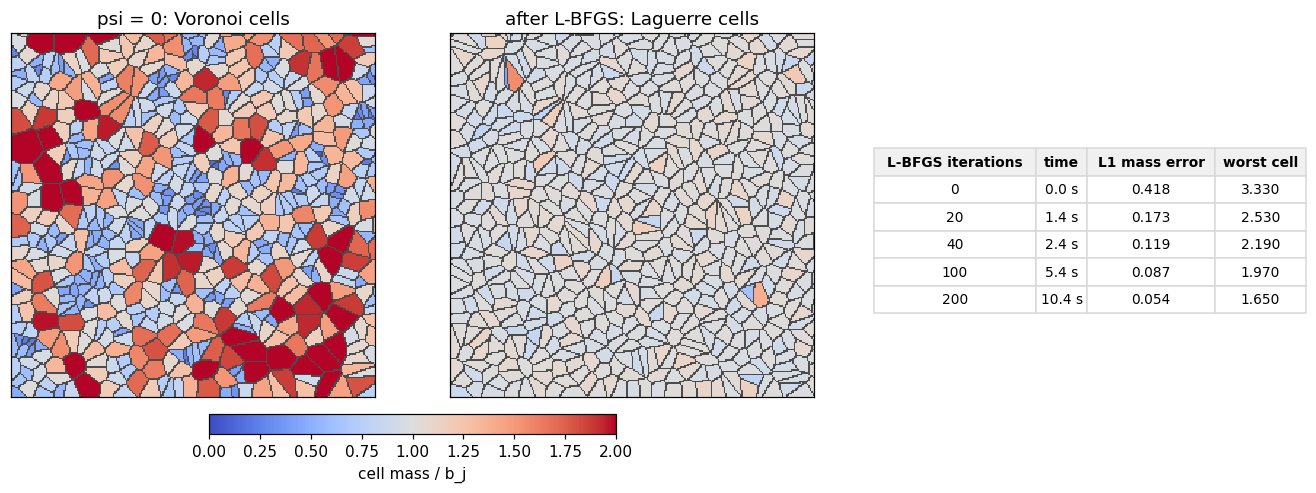